# SARSA and Expected SARSA

Compares the two on-policy TD control algorithms against each other and against
Q-learning as an off-policy baseline.

| Algorithm | Update target | Policy used for target |
|-----------|--------------|------------------------|
| **SARSA** | `cost + gamma * Q[s', a']` | epsilon-greedy (sampled) |
| **Expected SARSA** | `cost + gamma * sum_a pi(a|s') * Q[s',a]` | epsilon-greedy (expected) |
| *Q-learning* (reference) | `cost + gamma * min_a Q[s',a]` | greedy (off-policy) |

Key question: does replacing the sampled next action with the analytical
expectation reduce variance enough to improve convergence speed?

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from experiments.run_all import (
    load_config, run_algorithm, run_episode,
    _make_sarsa, _make_expected_sarsa, _make_q_learning,
)
from environment.gridworld import GridWorldEnv
from utils.plotting import (
    plot_multi_curves, plot_learning_curves,
    plot_value_heatmap, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar, save_figure,
)
from utils.metrics import V_STAR, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## 0. Hyperparameters

In [2]:
cfg = load_config()

print(f"gamma          = {cfg['environment']['gamma']}")
print(f"n_episodes     = {cfg['environment']['n_episodes']}")
print(f"omega          = {cfg['learning_rate']['omega']}  (alpha = 1/n^omega)")
print(f"epsilon_start  = {cfg['exploration']['epsilon_start']}")
print(f"epsilon_decay  = {cfg['exploration']['epsilon_decay']} per step")

gamma          = 0.85
n_episodes     = 1500
omega          = 0.8  (alpha = 1/n^omega)
epsilon_start  = 0.4
epsilon_decay  = 0.9 per step


## 1. Running the Experiments

3 runs for notebook speed. All three algorithms share identical hyperparameters;
the only difference is the Bellman target.

In [3]:
nb_cfg = {**cfg, 'environment': {**cfg['environment'], 'n_runs': 3}}

In [4]:
print('Running SARSA ...')
sarsa_results = run_algorithm('sarsa', _make_sarsa, nb_cfg, verbose=True)

Running SARSA ...


16:30:49  INFO      sarsa                   run 1/3  abs_err(final)=25.4571  3.6s
16:30:52  INFO      sarsa                   run 2/3  abs_err(final)=22.0333  6.9s
16:30:55  INFO      sarsa                   run 3/3  abs_err(final)=39.3999  10.1s


In [5]:
print('Running Expected SARSA ...')
esarsa_results = run_algorithm('expected_sarsa', _make_expected_sarsa, nb_cfg, verbose=True)

Running Expected SARSA ...


16:31:00  INFO      expected_sarsa          run 1/3  abs_err(final)=41.0605  3.5s
16:31:04  INFO      expected_sarsa          run 2/3  abs_err(final)=43.1023  7.1s
16:31:08  INFO      expected_sarsa          run 3/3  abs_err(final)=43.3453  11.1s


In [6]:
# Off-policy reference for comparison
print('Running Q-learning (reference) ...')
ql_results = run_algorithm('q_learning', _make_q_learning, nb_cfg, verbose=True)

Running Q-learning (reference) ...


16:31:12  INFO      q_learning              run 1/3  abs_err(final)=0.0823  0.7s
16:31:13  INFO      q_learning              run 2/3  abs_err(final)=0.0945  1.4s
16:31:14  INFO      q_learning              run 3/3  abs_err(final)=0.0975  2.1s


## 2. Learning Curves

Shaded bands = mean +/- 1 std across 3 runs.

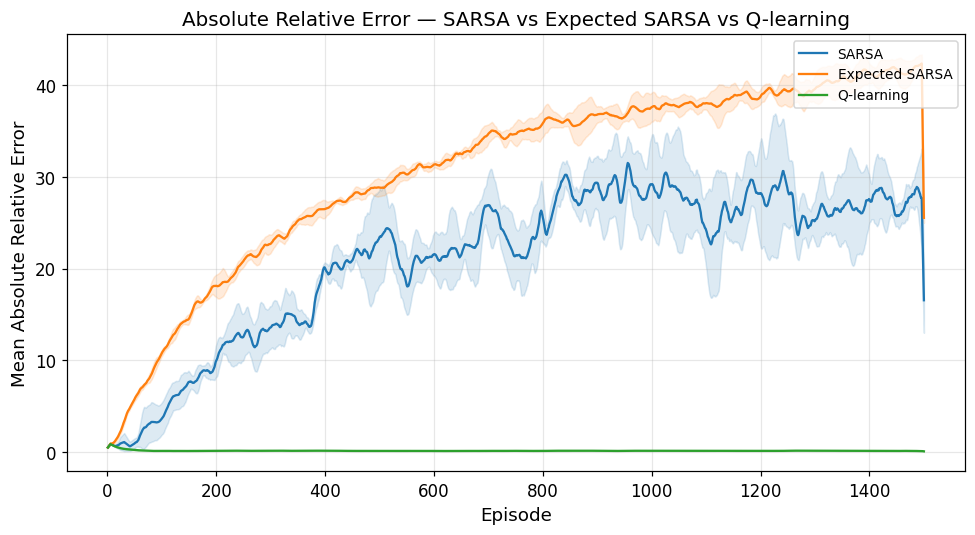

In [7]:
results_map = {
    'SARSA':          sarsa_results,
    'Expected SARSA': esarsa_results,
    'Q-learning':     ql_results,
}

fig = plot_multi_curves(
    results_map, metric='abs_err',
    title='Absolute Relative Error — SARSA vs Expected SARSA vs Q-learning',
    smooth=10,
)
save_figure(fig, '02_abs_err')
plt.show()

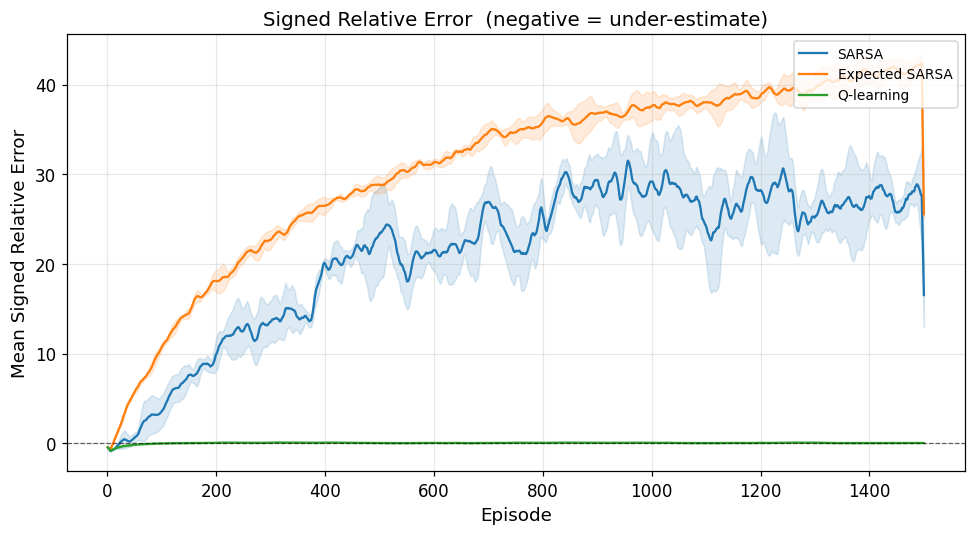

In [8]:
fig = plot_multi_curves(
    results_map, metric='signed_err',
    title='Signed Relative Error  (negative = under-estimate)',
    smooth=10,
)
for ax in fig.axes:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
save_figure(fig, '02_signed_err')
plt.show()

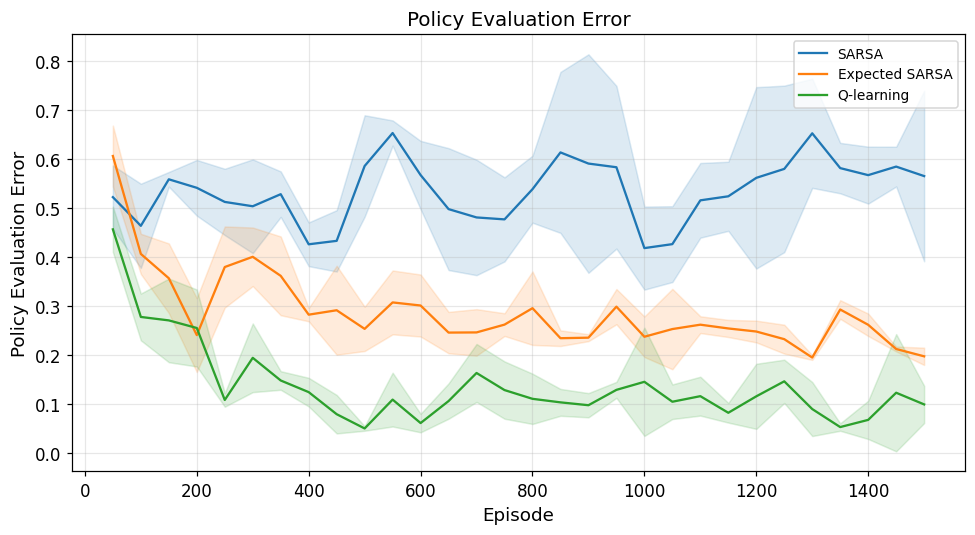

In [9]:
fig = plot_multi_curves(
    results_map, metric='policy_err',
    title='Policy Evaluation Error',
)
save_figure(fig, '02_policy_err')
plt.show()

## 3. Value Function Heatmaps

In [10]:
n_eps  = cfg['environment']['n_episodes']
max_st = cfg['environment']['max_steps_per_episode']

agents = {}
for name, factory in [('SARSA', _make_sarsa), ('Expected SARSA', _make_expected_sarsa)]:
    agent = factory(np.random.default_rng(42), cfg)
    env   = GridWorldEnv(np.random.default_rng(43))
    for ep in range(n_eps):
        run_episode(agent, env, max_st, ep)
    agents[name] = agent
    print(f'{name:<18}  policy_err={policy_eval_error(agent.get_policy()):.4f}')

SARSA               policy_err=0.7490
Expected SARSA      policy_err=0.3895


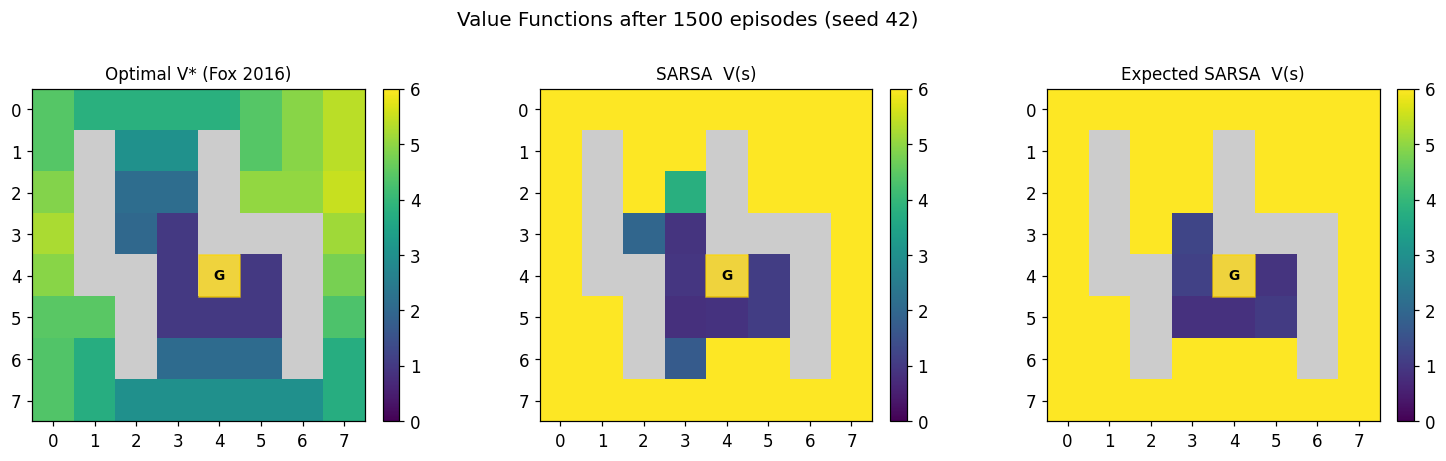

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_vstar_heatmap(ax=axes[0])
plot_value_heatmap(agents['SARSA'].get_value_estimate(),
                   title='SARSA  V(s)', ax=axes[1], vmin=0, vmax=6)
plot_value_heatmap(agents['Expected SARSA'].get_value_estimate(),
                   title='Expected SARSA  V(s)', ax=axes[2], vmin=0, vmax=6)
fig.suptitle('Value Functions after 1500 episodes (seed 42)', fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, '02_value_heatmaps')
plt.show()

## 4. Policy Visualisation

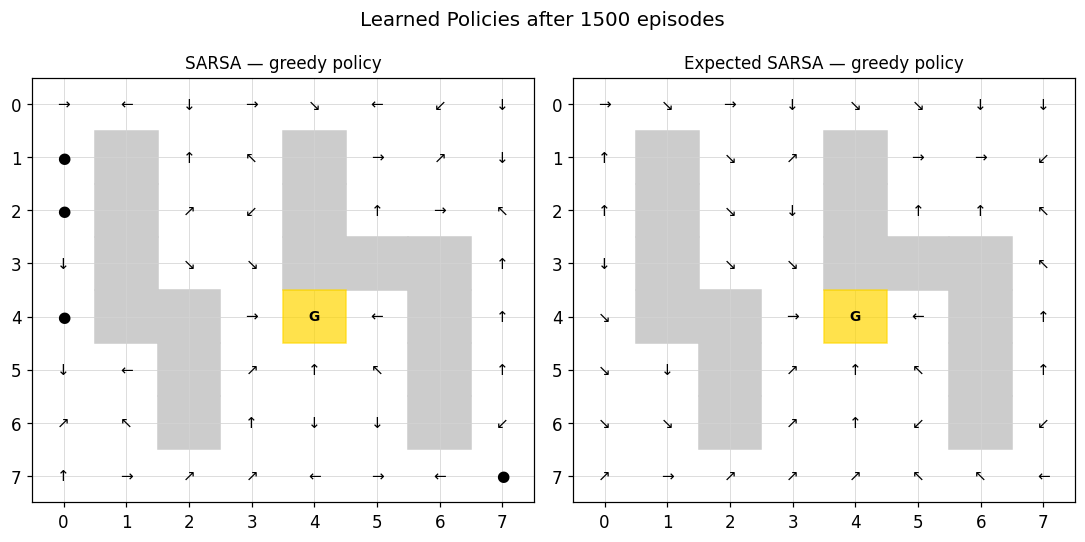

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_policy_arrows(agents['SARSA'].get_policy(),
                   title='SARSA — greedy policy', ax=axes[0])
plot_policy_arrows(agents['Expected SARSA'].get_policy(),
                   title='Expected SARSA — greedy policy', ax=axes[1])
fig.suptitle('Learned Policies after 1500 episodes', fontsize=13)
fig.tight_layout()
save_figure(fig, '02_policy_arrows')
plt.show()

## 5. Summary

SARSA               abs_err=28.9634+/-7.5109  policy_err=0.5659+/-0.1739
Expected SARSA      abs_err=42.5027+/-1.0246  policy_err=0.1980+/-0.0177
Q-learning          abs_err=0.0914+/-0.0065  policy_err=0.0998+/-0.0380


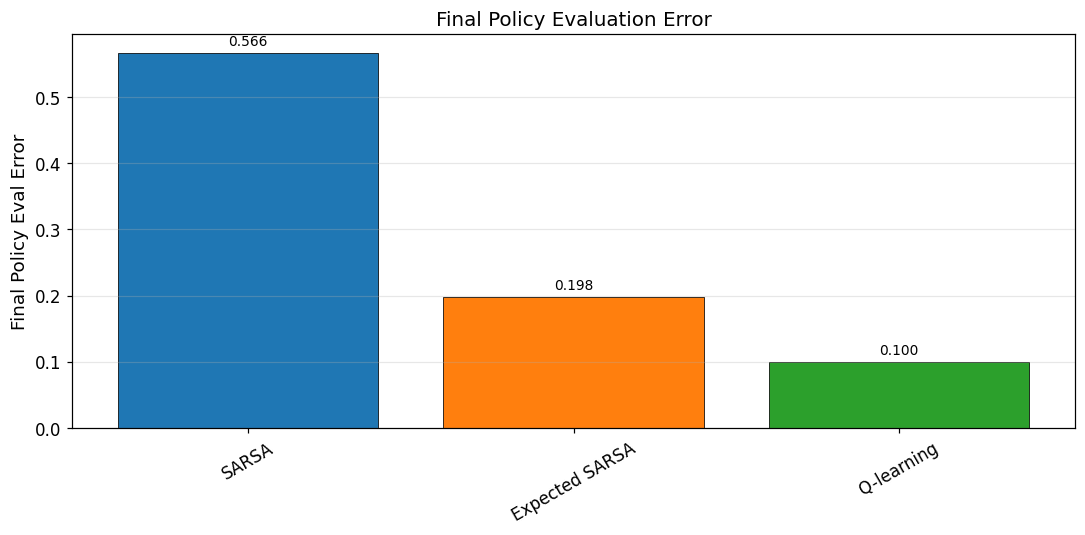

In [13]:
def final_stats(res, name):
    ae_m = res['abs_err'][:, -1].mean()
    ae_s = res['abs_err'][:, -1].std()
    pe_m = res['policy_err'][:, -1].mean()
    pe_s = res['policy_err'][:, -1].std()
    print(f'{name:<18}  abs_err={ae_m:.4f}+/-{ae_s:.4f}  '
          f'policy_err={pe_m:.4f}+/-{pe_s:.4f}')
    return pe_m

final_pol = {
    'SARSA':          final_stats(sarsa_results,  'SARSA'),
    'Expected SARSA': final_stats(esarsa_results, 'Expected SARSA'),
    'Q-learning':     final_stats(ql_results,     'Q-learning'),
}

fig = plot_summary_bar(final_pol, title='Final Policy Evaluation Error')
save_figure(fig, '02_final_bar')
plt.show()

## 6. Hyperparameter Tuning

Both SARSA and Expected SARSA share the same ε-greedy schedule and count-based LR.
We tune ω (LR exponent) and ε₀ (initial exploration), sweeping one at a time.

In [ ]:
from algorithms.sarsa import SARSAAgent
from algorithms.expected_sarsa import ExpectedSARSAAgent
from utils.metrics import policy_eval_error

GAMMA  = cfg['environment']['gamma']
N_EPS  = cfg['environment']['n_episodes']
MAX_ST = cfg['environment']['max_steps_per_episode']
TUNE_RUNS = 3

def run_sweep_sarsa(factory, n_runs=TUNE_RUNS, n_eps=N_EPS, max_steps=MAX_ST, base_seed=0):
    errors = []
    for run in range(n_runs):
        rng_a = np.random.default_rng(base_seed + run * 1000)
        rng_e = np.random.default_rng(base_seed + run * 1000 + 1)
        agent = factory(rng_a)
        env   = GridWorldEnv(rng_e)
        for ep in range(n_eps):
            run_episode(agent, env, max_steps, ep)
        errors.append(policy_eval_error(agent.get_policy()))
    return float(np.mean(errors))

### 6a. LR Exponent ω

Swept over {0.6, 0.7, 0.8, 0.9, 1.0} for both SARSA and Expected SARSA.

In [ ]:
omega_vals  = [0.6, 0.7, 0.8, 0.9, 1.0]
eps_start   = cfg['exploration']['epsilon_start']
eps_decay   = cfg['exploration']['epsilon_decay']

omega_sarsa  = {}
omega_esarsa = {}
for om in omega_vals:
    omega_sarsa[om]  = run_sweep_sarsa(lambda rng, om=om: SARSAAgent(
        rng, GAMMA, omega=om, epsilon_start=eps_start, epsilon_decay=eps_decay))
    omega_esarsa[om] = run_sweep_sarsa(lambda rng, om=om: ExpectedSARSAAgent(
        rng, GAMMA, omega=om, epsilon_start=eps_start, epsilon_decay=eps_decay))
    print(f'  omega={om:.1f}  SARSA={omega_sarsa[om]:.4f}  ExpSARSA={omega_esarsa[om]:.4f}')

best_omega_sarsa  = min(omega_sarsa,  key=omega_sarsa.get)
best_omega_esarsa = min(omega_esarsa, key=omega_esarsa.get)
print(f'\nBest omega — SARSA: {best_omega_sarsa}, Expected SARSA: {best_omega_esarsa}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(omega_vals, [omega_sarsa[o]  for o in omega_vals], 'o-', label='SARSA')
ax.plot(omega_vals, [omega_esarsa[o] for o in omega_vals], 's--', label='Expected SARSA')
ax.set_xlabel('ω'); ax.set_ylabel('Final policy_err')
ax.set_title('SARSA variants: LR Exponent Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '02_tune_omega')
plt.show()

### 6b. Initial Epsilon ε₀

Fixes ω at the best value found above; sweeps ε₀ ∈ {0.1, 0.2, 0.4, 0.6, 0.8}.

In [ ]:
eps_vals = [0.1, 0.2, 0.4, 0.6, 0.8]
best_omega = min(best_omega_sarsa, best_omega_esarsa)  # use the better of the two

eps_sarsa  = {}
eps_esarsa = {}
for es in eps_vals:
    eps_sarsa[es]  = run_sweep_sarsa(lambda rng, es=es: SARSAAgent(
        rng, GAMMA, omega=best_omega, epsilon_start=es, epsilon_decay=eps_decay))
    eps_esarsa[es] = run_sweep_sarsa(lambda rng, es=es: ExpectedSARSAAgent(
        rng, GAMMA, omega=best_omega, epsilon_start=es, epsilon_decay=eps_decay))
    print(f'  eps={es:.1f}  SARSA={eps_sarsa[es]:.4f}  ExpSARSA={eps_esarsa[es]:.4f}')

best_eps_sarsa  = min(eps_sarsa,  key=eps_sarsa.get)
best_eps_esarsa = min(eps_esarsa, key=eps_esarsa.get)
print(f'\nBest epsilon_start — SARSA: {best_eps_sarsa}, Expected SARSA: {best_eps_esarsa}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(eps_vals, [eps_sarsa[e]  for e in eps_vals], 'o-', label='SARSA')
ax.plot(eps_vals, [eps_esarsa[e] for e in eps_vals], 's--', label='Expected SARSA')
ax.set_xlabel('ε₀'); ax.set_ylabel('Final policy_err')
ax.set_title('SARSA variants: Initial Epsilon Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '02_tune_eps')
plt.show()

In [ ]:
print('=' * 50)
print('TUNED HYPERPARAMETERS — update default.yaml with these values')
print('=' * 50)
# Use the epsilon that performs best averaged across both algorithms
import statistics
combined_eps = {e: (eps_sarsa[e] + eps_esarsa[e]) / 2 for e in eps_vals}
best_eps_combined = min(combined_eps, key=combined_eps.get)
combined_omega = {o: (omega_sarsa[o] + omega_esarsa[o]) / 2 for o in omega_vals}
best_omega_combined = min(combined_omega, key=combined_omega.get)
print(f'  learning_rate.omega       : {best_omega_combined}')
print(f'  exploration.epsilon_start : {best_eps_combined}')

## Discussion

**SARSA** is on-policy: the action `a'` used in the TD target is the same
epsilon-greedy action that will actually be taken next. This means SARSA
evaluates the *exploration policy*, not the greedy policy, and is therefore
more conservative near the optimal in environments with high wall-collision
risk — it will not greedily step toward the goal if the epsilon-greedy policy
would sometimes walk into a wall.

**Expected SARSA** replaces the sampled next action with the analytical
expectation over all actions under the current epsilon-greedy policy:

```
E_pi[Q[s', a']] = epsilon/9 * sum_a Q[s', a] + (1 - epsilon) * min_a Q[s', a]
```

This removes the per-step variance introduced by sampling `a'`, often leading
to smoother and faster convergence than vanilla SARSA. As epsilon -> 0,
Expected SARSA's target converges to Q-learning's hard minimum.

The three algorithms occupy a spectrum:
- **SARSA**: on-policy, noisy target (sampled a')
- **Expected SARSA**: on-policy, lower-variance target (averaged a')
- **Q-learning**: off-policy, minimum target (fully greedy)